In [16]:
# add a "Open in Colab" button to this notebook
# https://colab.research.google.com/github/username/repo/blob/branch/path/to/notebook.ipynb


# Data Vis: Introduction
* Notebook 1: Live Coding

## Setup

Install packages in case you are working on Google Colab.

In [17]:
#!pip install gapminder

Import packages.

In [18]:
import pandas as pd
import numpy as np
from gapminder import gapminder
from matplotlib import pyplot as plt
from sklearn.preprocessing import minmax_scale

## Data

The Gapminder dataset is a collection of data about life expectancy, GDP per capita, and population for various countries over time. It is often used to illustrate trends in global development. It was created by Hans Rosling and is available on the Gapminder website (https://www.gapminder.org/) or throught the gapminder package.

In [19]:
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


## Your First Plot

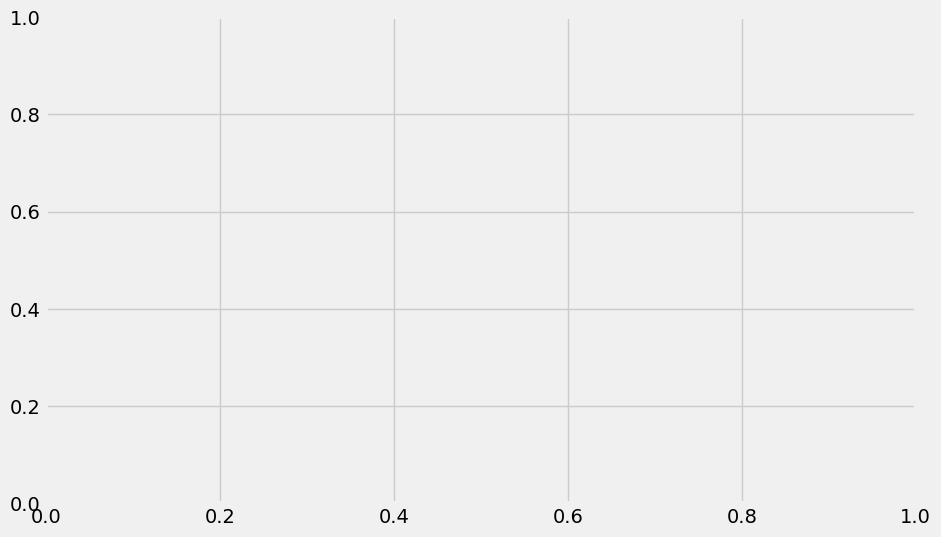

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.show()

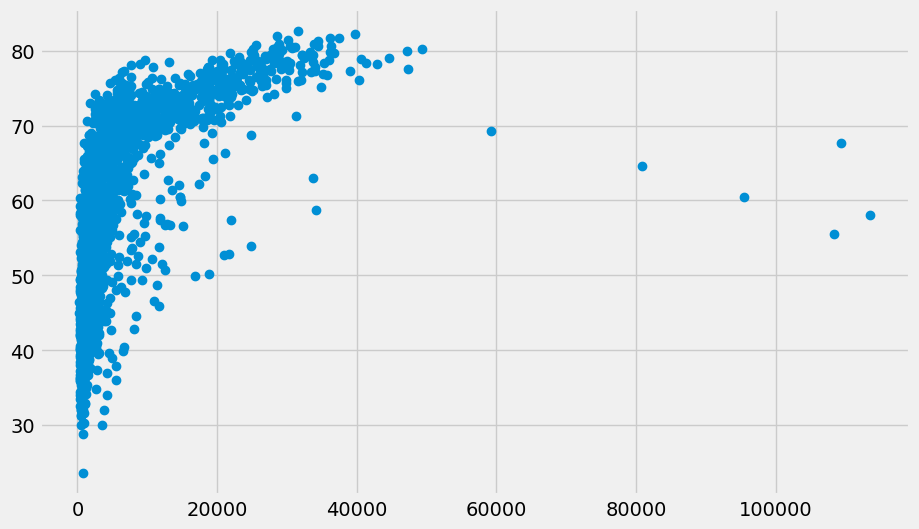

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(gapminder["gdpPercap"], gapminder["lifeExp"], marker="o", linestyle="none")
plt.show()

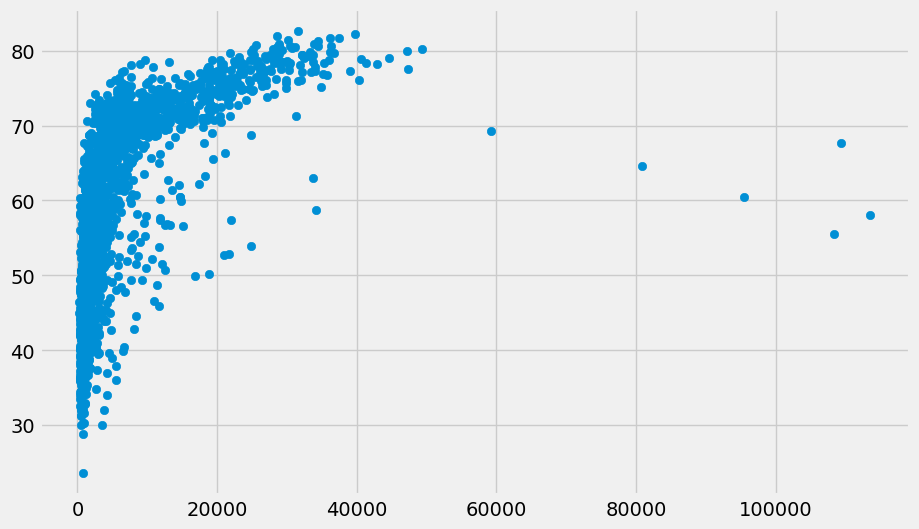

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gapminder["gdpPercap"], gapminder["lifeExp"])
plt.show()

## Mapping Data to Visuals

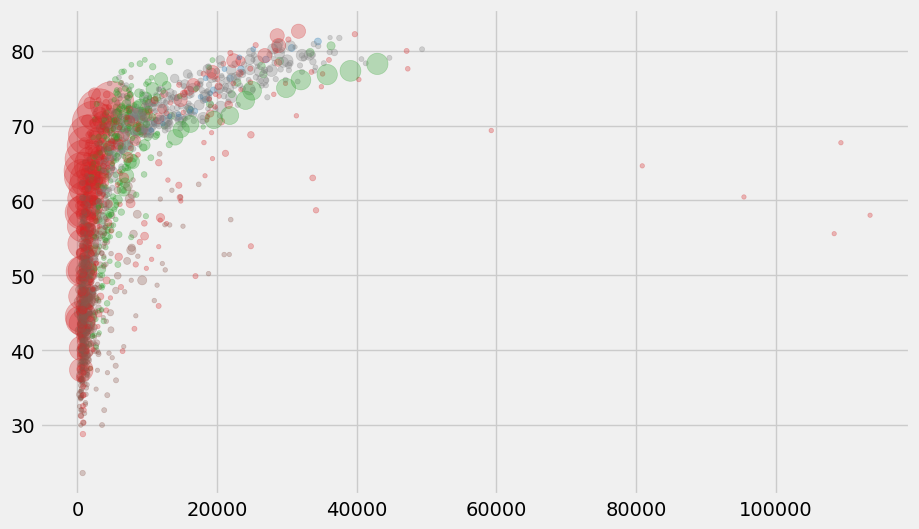

In [23]:
# size, color
colors = {'Africa':'tab:brown', 'Asia':'tab:red', 'Europe':'tab:grey', 'Americas':'tab:green', 'Oceania':'tab:blue'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gapminder["gdpPercap"], gapminder["lifeExp"], s=minmax_scale(gapminder["pop"], (10,1000)), c=gapminder["continent"].map(colors), alpha=0.3)
plt.show()

## Adding Layers

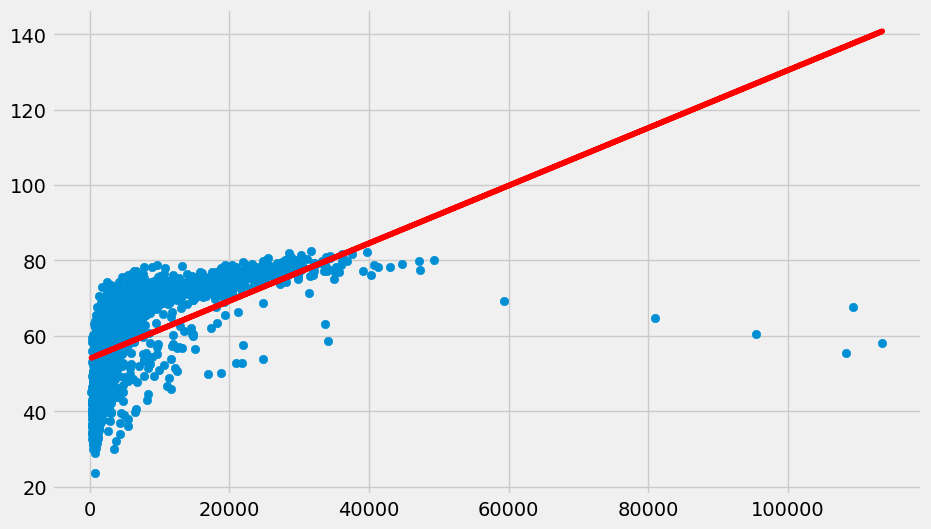

In [24]:
b1, b0 = np.polyfit(gapminder["gdpPercap"], gapminder["lifeExp"], deg=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gapminder["gdpPercap"], gapminder["lifeExp"])
ax.plot(gapminder["gdpPercap"], b0 + b1*gapminder["gdpPercap"], color="red")
plt.show()

## Tuning the Plot

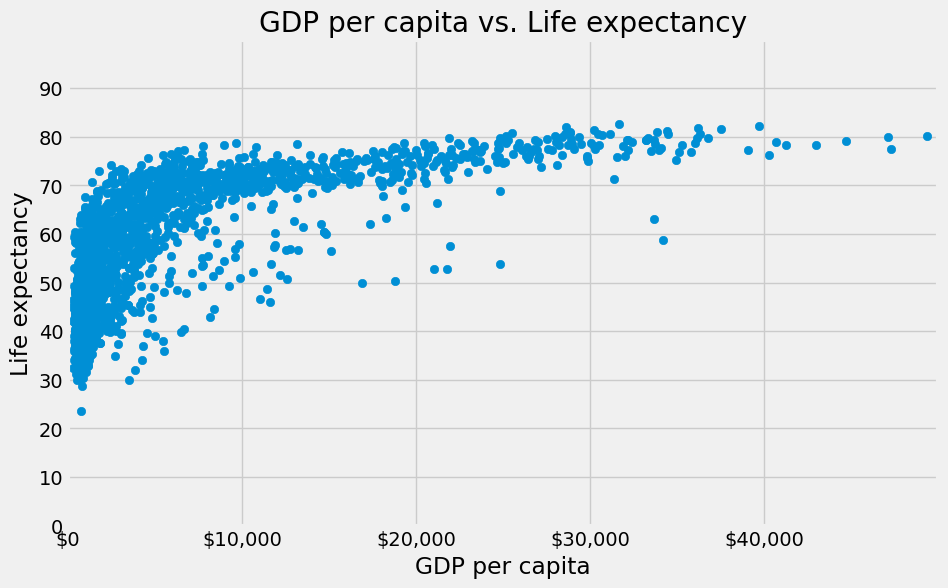

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gapminder["gdpPercap"], gapminder["lifeExp"])
ax.set_title("GDP per capita vs. Life expectancy")
ax.set_xlabel("GDP per capita")
ax.set_ylabel("Life expectancy")
ax.set_xlim(0, 50000)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 50000, 10000))
ax.set_yticks(np.arange(0, 100, 10))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.show()


## Changing Scales

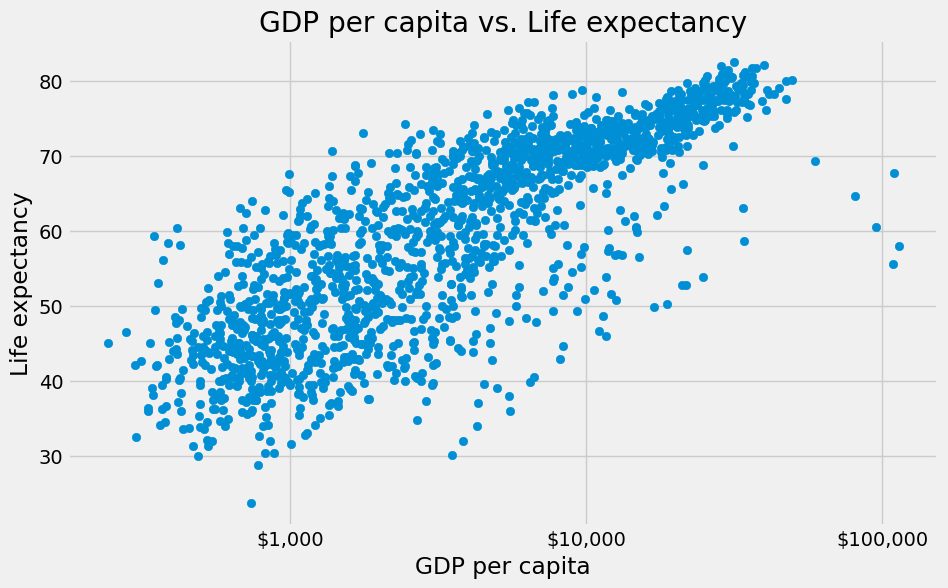

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gapminder["gdpPercap"], gapminder["lifeExp"])
ax.set_title("GDP per capita vs. Life expectancy")
ax.set_xlabel("GDP per capita")
ax.set_ylabel("Life expectancy")
ax.set_xscale("log")
#ax.set_xlim(0, 100000)
#ax.set_ylim(0, 100)
#ax.set_xticks(np.arange(, 100000, 10000))
#ax.set_yticks(np.arange(0, 100, 10))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.show()


## Small Multiples

In [27]:
gapminder_europe = gapminder[gapminder["continent"] == "Europe"]
gapminder_asia = gapminder[gapminder["continent"] == "Asia"]

In [28]:
set(gapminder["continent"])

{'Africa', 'Americas', 'Asia', 'Europe', 'Oceania'}

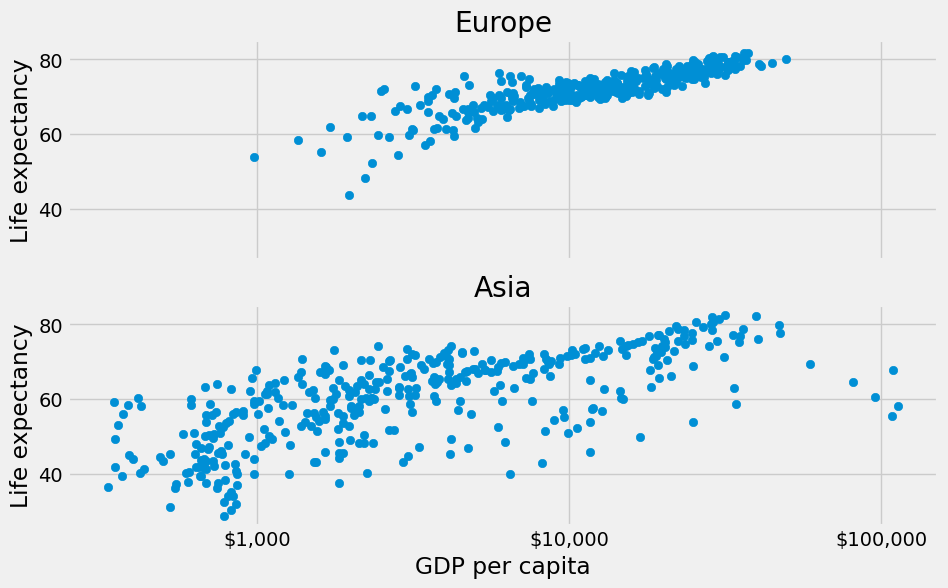

In [29]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
ax[0].scatter(gapminder_europe["gdpPercap"], gapminder_europe["lifeExp"])
ax[1].scatter(gapminder_asia["gdpPercap"], gapminder_asia["lifeExp"])
ax[0].set_title("Europe")
ax[1].set_title("Asia")
for i in range(2):
    ax[i].set_ylabel("Life expectancy")
    ax[i].set_xscale("log")
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
ax[1].set_xlabel("GDP per capita")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.show()

## Theming

Matplotlib has a number of built-in style sheets that can be used to change the overall appearance of your plots (https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html). You can also create your own custom themes by defining a set of style parameters.

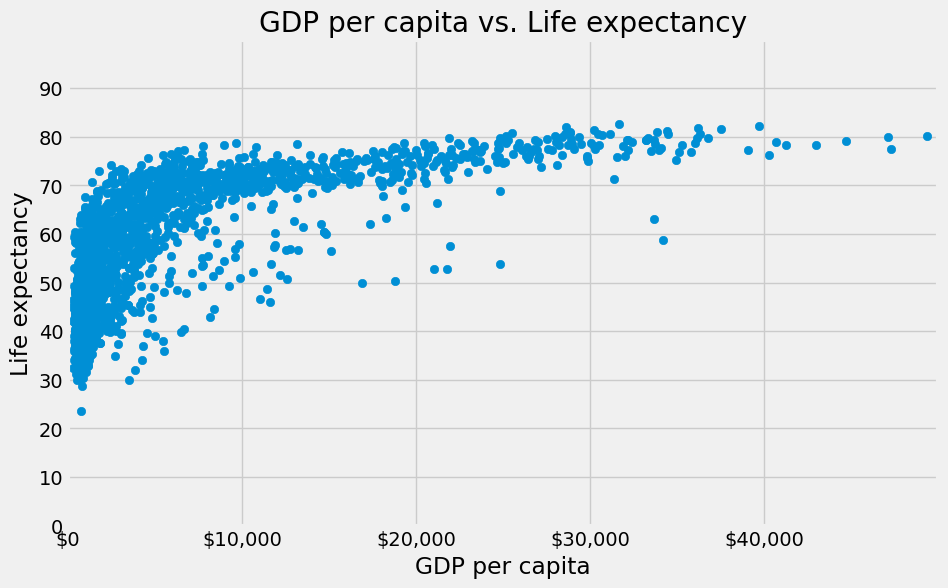

In [30]:
plt.style.use('fivethirtyeight')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gapminder["gdpPercap"], gapminder["lifeExp"])
ax.set_title("GDP per capita vs. Life expectancy")
ax.set_xlabel("GDP per capita")
ax.set_ylabel("Life expectancy")
ax.set_xlim(0, 50000)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 50000, 10000))
ax.set_yticks(np.arange(0, 100, 10))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.show()
